This script will test my version vs Thomas's for the following:


- LCDM 
- Non interacting ncdm
- Interacting ncdm


In [1]:
"""
compare_lcdm_fs_int_ncdm.py

Compare Thomas (CLASS wrapper: classy) vs Mine (classy_NEDE) in three clean regimes:

  0) ΛCDM baseline (no split keys; vanilla behavior)
  1) Free-streaming ncdm comparison:
       - Thomas: legacy ncdm keys (N_ncdm, m_ncdm, deg_ncdm)
       - Mine: split keys (N_ncdm_standard=1, N_ncdm_interacting=0) + legacy m/deg
  2) Interacting ncdm comparison:
       - Thomas: interacting interface keys (N_ncdm_interacting, m_ncdm_interacting, deg_ncdm_interacting, G_eff_ncdm_interacting)
       - Mine: split keys (N_ncdm_standard=0, N_ncdm_interacting=1) + legacy m/deg + G_eff_ncdm_interacting

We compute linear P(k,z=0) on a common physical k [1/Mpc] grid and convert to
(Mpc/h)^3 using Thomas h as reference for plotting.

This script is designed to avoid *any* accidental mixing of legacy + split interfaces.
"""


import numpy as np
import matplotlib.pyplot as plt

from classy import Class as ClassThomas
from classy_NEDE import Class as ClassMine


In [2]:
# =============================================================================
# Helpers
# =============================================================================
def pk_safe(cosmo, k_1Mpc_arr, z):
    fn = cosmo.pk_lin if hasattr(cosmo, "pk_lin") else cosmo.pk
    return np.array([fn(float(k), float(z)) for k in k_1Mpc_arr])

def run(Cls, params, label):
    c = Cls()
    c.set(params)
    c.compute()
    try:
        d = c.get_current_derived_parameters(["h", "Omega_m", "Omega_r"])
        print(f"[{label}] derived:", d)
    except Exception:
        try:
            print(f"[{label}] h={c.h():.6f}")
        except Exception:
            print(f"[{label}] computed.")
    return c

def cleanup(*cosmos):
    for c in cosmos:
        try:
            c.struct_cleanup()
            c.empty()
        except Exception:
            pass

def plot_two_panel(k_hMpc, Pk_T, Pk_M, title):
    dev = Pk_M / Pk_T - 1.0

    fig, (ax1, ax2) = plt.subplots(
        2, 1, figsize=(7, 8),
        sharex=True,
        gridspec_kw={"height_ratios": [3, 1]}
    )

    ax1.loglog(k_hMpc, Pk_T, label="Thomas")
    ax1.loglog(k_hMpc, Pk_M, ls="--", label="Mine")
    ax1.set_ylabel(r"$P(k)\,[(\mathrm{Mpc}/h)^3]$")
    ax1.set_title(title)
    ax1.legend()
    ax1.grid(True, which="both", ls=":")

    ax2.semilogx(k_hMpc, dev)
    ax2.axhline(0.0, ls=":")
    ax2.set_xlabel(r"$k\,[h/\mathrm{Mpc}]$")
    ax2.set_ylabel("Mine/Thomas - 1")
    ax2.grid(True, which="both", ls=":")

    plt.tight_layout()
    plt.show()
    print(f"  max |Mine/Thomas - 1| = {np.max(np.abs(dev)):.3e}")

In [3]:
# =============================================================================
# BASE COSMOLOGICAL PARAMETERS
# =============================================================================
H0        = 67.32
omega_b   = 0.02238
omega_cdm = 0.1201
A_s       = 2.101e-9
n_s       = 0.9660
tau_reio  = 0.0543
k_pivot   = 0.05
T_cmb     = 2.7255
Omega_k   = 0.0

# baseline (used for FS/INT scaffolding)
N_ncdm_base   = 1
m_ncdm_base   = 0.06
T_ncdm_base   = 0.71611
deg_ncdm_base = 1.0
N_ur_base     = max(0.0, 3.046 - float(deg_ncdm_base))

K_1MPC = np.logspace(-4, 1.0, 250)
Z_PK   = 0.0
L_MAX  = 2500

def base_params(lmax: int) -> dict:
    """Baseline parameter dict. Individual runs override neutrino keys explicitly."""
    return {
        "H0"            : float(H0),
        "omega_b"       : float(omega_b),
        "omega_cdm"     : float(omega_cdm),
        "A_s"           : float(A_s),
        "n_s"           : float(n_s),
        "tau_reio"      : float(tau_reio),
        "k_pivot"       : float(k_pivot),
        "T_cmb"         : float(T_cmb),
        "Omega_k"       : float(Omega_k),

        # baseline neutrino content (overridden per run)
        "N_ur"          : float(N_ur_base),
        "N_ncdm"        : int(N_ncdm_base),
        "m_ncdm"        : float(m_ncdm_base),
        "T_ncdm"        : float(T_ncdm_base),
        "deg_ncdm"      : float(deg_ncdm_base),

        "recombination"        : "recfast",
        "reio_parametrization" : "reio_camb",

        "output"        : "tCl,pCl,lCl,mPk",
        "lensing"       : "yes",
        "l_max_scalars" : int(lmax),
        "P_k_max_1/Mpc" : float(np.max(K_1MPC) * 1.05),
    }

print("Base parameters loaded.")
print(f"  H0       = {H0} km/s/Mpc")
print(f"  omega_b  = {omega_b}")
print(f"  omega_cdm= {omega_cdm}")
print(f"  N_ur(base)= {N_ur_base:.6g}   (budget convention: 3.046 - deg_ncdm)")
print(f"  k-grid   = [{K_1MPC.min():.1e}, {K_1MPC.max():.1e}] 1/Mpc  (N={len(K_1MPC)})")

Base parameters loaded.
  H0       = 67.32 km/s/Mpc
  omega_b  = 0.02238
  omega_cdm= 0.1201
  N_ur(base)= 2.046   (budget convention: 3.046 - deg_ncdm)
  k-grid   = [1.0e-04, 1.0e+01] 1/Mpc  (N=250)


Compute the LCDM power spectrum


RUN 0: True ΛCDM (no massive ncdm)
[Thomas LCDM (true)] h=0.673200
[Mine   LCDM (true)] h=0.673200
has_efld = 0, Omega0_efld = 0.000000e+00, w0_efld = -1.000000e+00
DEBUG split(prepass): legacy_flag=0 legacy_N=0  flag_std=0 flag_int=0  Nstd_in=0 Nint_in=0  => Nstd=0 Nint=0 Ntot=0 (local N_ncdm=0)


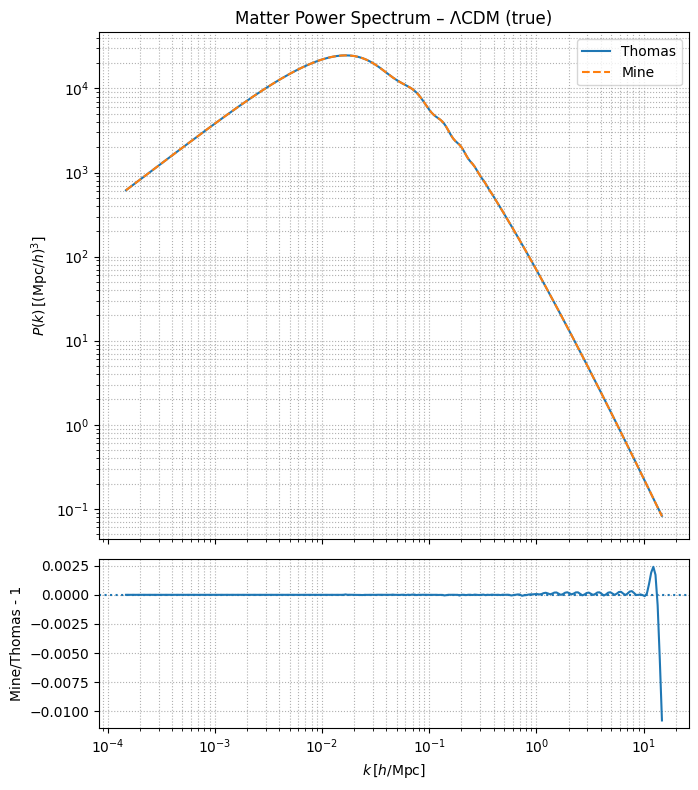

  max |Mine/Thomas - 1| = 1.080e-02


In [4]:
# =============================================================================
# 0) RUN: True ΛCDM
# =============================================================================
print("\n==============================")
print("RUN 0: True ΛCDM (no massive ncdm)")
print("==============================")

# Thomas LCDM(true): legacy ok -> explicitly set N_ncdm=0
pT_lcdm = base_params(L_MAX)
pT_lcdm.update({"N_ur": 3.046, "N_ncdm": 0})
for key in ["m_ncdm", "deg_ncdm", "T_ncdm",
            "N_ncdm_standard", "N_ncdm_interacting",
            "m_ncdm_standard", "deg_ncdm_standard",
            "m_ncdm_interacting", "deg_ncdm_interacting",
            "G_eff_ncdm_interacting", "log10G_eff_ncdm_interacting",
            "ncdm_fluid_approximation"]:
    pT_lcdm.pop(key, None)

# Mine LCDM(true): IMPORTANT -> do NOT set ANY ncdm count keys at all
pM_lcdm = base_params(L_MAX)
pM_lcdm.update({"N_ur": 3.046})
for key in [
    # kill legacy + split counters (must be ABSENT to avoid your split-sum>0 check)
    "N_ncdm", "N_ncdm_standard", "N_ncdm_interacting",
    # kill ncdm descriptors/couplings
    "m_ncdm", "deg_ncdm", "T_ncdm",
    "m_ncdm_standard", "deg_ncdm_standard",
    "m_ncdm_interacting", "deg_ncdm_interacting",
    "G_eff_ncdm_interacting", "log10G_eff_ncdm_interacting",
    "G_eff_ncdm", "log10_G_eff_ncdm",
    "ncdm_fluid_approximation",
]:
    pM_lcdm.pop(key, None)

cT_lcdm = run(ClassThomas, pT_lcdm, "Thomas LCDM (true)")
cM_lcdm = run(ClassMine,   pM_lcdm, "Mine   LCDM (true)")

h_ref = float(cT_lcdm.h())
k_hMpc = K_1MPC / h_ref

PkT_lcdm = pk_safe(cT_lcdm, K_1MPC, Z_PK) * h_ref**3
PkM_lcdm = pk_safe(cM_lcdm, K_1MPC, Z_PK) * h_ref**3

plot_two_panel(k_hMpc, PkT_lcdm, PkM_lcdm, "Matter Power Spectrum – ΛCDM (true)")


RUN 1: Free-streaming ncdm (FS)
has_efld = 0, Omega0_efld = 0.000000e+00, w0_efld = -1.000000e+00
[Thomas FS] h=0.673200
DEBUG split(prepass): legacy_flag=0 legacy_N=0  flag_std=1 flag_int=1  Nstd_in=1 Nint_in=0  => Nstd=1 Nint=0 Ntot=1 (local N_ncdm=1)
DEBUG split(Geff_final): Nstd=1 Nint=0 Ntot=1  Geff_species=0.000e+00
[Mine   FS] h=0.673200


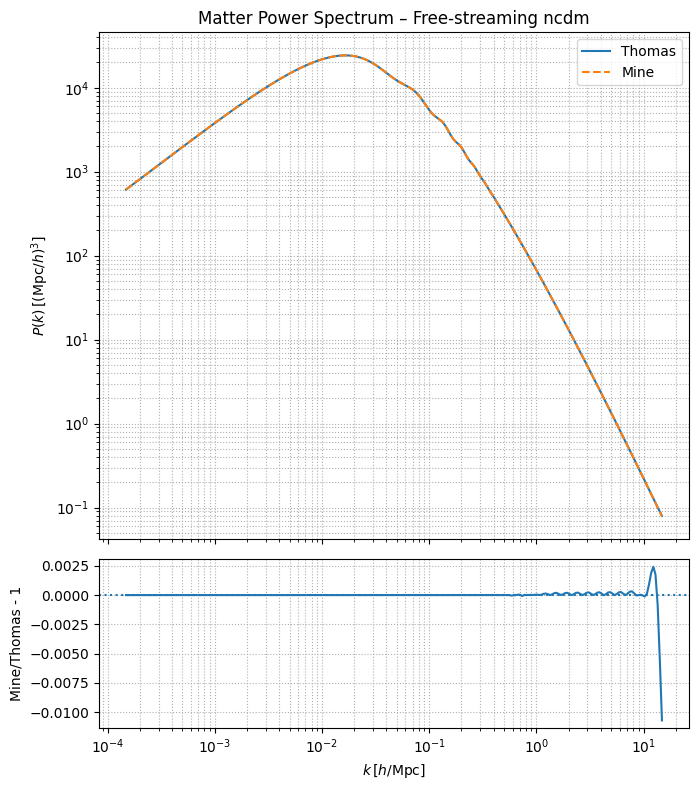

  max |Mine/Thomas - 1| = 1.071e-02


In [5]:
# =============================================================================
# 1) RUN: Free-streaming ncdm (FS)
# =============================================================================
print("\n==============================")
print("RUN 1: Free-streaming ncdm (FS)")
print("==============================")

M_NCDM_EV = 0.06
DEG_NCDM  = 1.0
N_ur_run  = max(0.0, 3.046 - float(DEG_NCDM))

# Thomas FS: legacy keys
pT_fs = base_params(L_MAX)
pT_fs.update({
    "N_ur"     : float(N_ur_run),
    "N_ncdm"   : 1,
    "m_ncdm"   : float(M_NCDM_EV),
    "deg_ncdm" : float(DEG_NCDM),
})

# Mine FS: split keys (must NOT include N_ncdm)
pM_fs = base_params(L_MAX)
pM_fs.update({
    "N_ur"               : float(N_ur_run),
    "N_ncdm_standard"    : 1,
    "N_ncdm_interacting" : 0,
    "m_ncdm"             : float(M_NCDM_EV),
    "deg_ncdm"           : float(DEG_NCDM),
})
pM_fs.pop("N_ncdm", None)  # avoid legacy+split conflict

cT_fs = run(ClassThomas, pT_fs, "Thomas FS")
cM_fs = run(ClassMine,   pM_fs, "Mine   FS")

h_ref = float(cT_fs.h())
k_hMpc = K_1MPC / h_ref

PkT_fs = pk_safe(cT_fs, K_1MPC, Z_PK) * h_ref**3
PkM_fs = pk_safe(cM_fs, K_1MPC, Z_PK) * h_ref**3

plot_two_panel(k_hMpc, PkT_fs, PkM_fs, "Matter Power Spectrum – Free-streaming ncdm")
cleanup(cT_fs, cM_fs)


RUN 2: Interacting ncdm (INT)
has_efld = 0, Omega0_efld = 0.000000e+00, w0_efld = -1.000000e+00
[Thomas INT] h=0.673200
DEBUG split(prepass): legacy_flag=0 legacy_N=0  flag_std=1 flag_int=1  Nstd_in=0 Nint_in=1  => Nstd=0 Nint=1 Ntot=1 (local N_ncdm=1)
DEBUG split(Geff_final): Nstd=0 Nint=1 Ntot=1  Geff_species=1.000e-01
[Mine   INT] h=0.673200


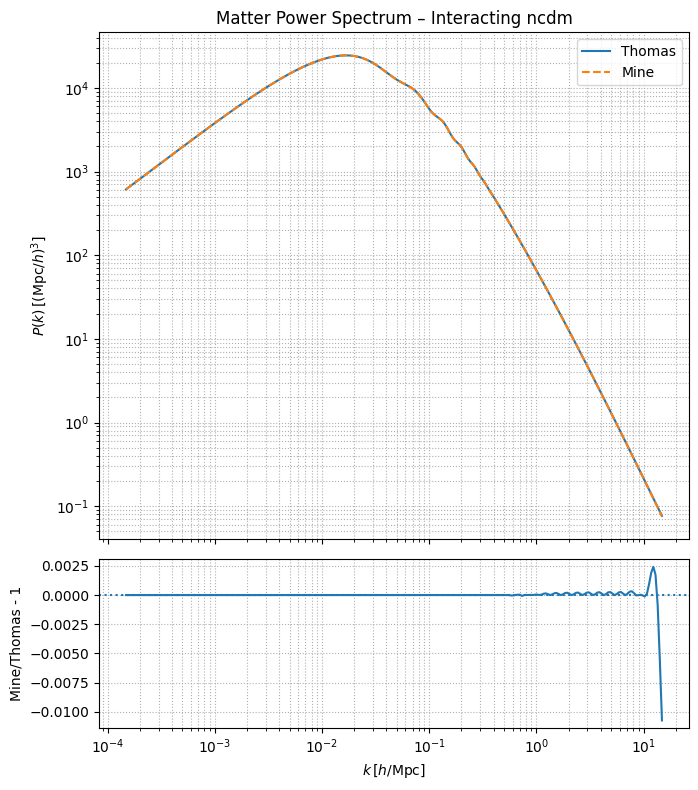

  max |Mine/Thomas - 1| = 1.074e-02

DONE (Thomas vs Mine comparisons).


In [6]:
# =============================================================================
# 2) RUN: Interacting ncdm (INT)
# =============================================================================
print("\n==============================")
print("RUN 2: Interacting ncdm (INT)")
print("==============================")

G_EFF_NCDM_ON = 1e-1

# Thomas INT: interacting interface only
pT_int = base_params(L_MAX)
pT_int.update({
    "N_ur"                   : float(N_ur_run),
    "N_ncdm_interacting"     : 1,
    "m_ncdm_interacting"     : float(M_NCDM_EV),
    "deg_ncdm_interacting"   : float(DEG_NCDM),
    "G_eff_ncdm_interacting" : float(G_EFF_NCDM_ON),
})
for key in ["N_ncdm", "m_ncdm", "deg_ncdm", "T_ncdm"]:
    pT_int.pop(key, None)

# Mine INT: split keys + legacy arrays for m/deg
pM_int = base_params(L_MAX)
pM_int.update({
    "N_ur"                   : float(N_ur_run),
    "N_ncdm_standard"        : 0,
    "N_ncdm_interacting"     : 1,
    "m_ncdm"                 : float(M_NCDM_EV),
    "deg_ncdm"               : float(DEG_NCDM),
    "G_eff_ncdm_interacting" : float(G_EFF_NCDM_ON),
})
pM_int.pop("N_ncdm", None)

cT_int = run(ClassThomas, pT_int, "Thomas INT")
cM_int = run(ClassMine,   pM_int, "Mine   INT")

h_ref = float(cT_int.h())
k_hMpc = K_1MPC / h_ref

PkT_int = pk_safe(cT_int, K_1MPC, Z_PK) * h_ref**3
PkM_int = pk_safe(cM_int, K_1MPC, Z_PK) * h_ref**3

plot_two_panel(k_hMpc, PkT_int, PkM_int, "Matter Power Spectrum – Interacting ncdm")
cleanup(cT_int, cM_int)

print("\nDONE (Thomas vs Mine comparisons).")


MINE ONLY: Overlay + Ratios
DEBUG split(prepass): legacy_flag=0 legacy_N=0  flag_std=0 flag_int=0  Nstd_in=0 Nint_in=0  => Nstd=0 Nint=0 Ntot=0 (local N_ncdm=0)
[Mine ΛCDM (true)] h=0.673200
DEBUG split(prepass): legacy_flag=0 legacy_N=0  flag_std=1 flag_int=1  Nstd_in=1 Nint_in=0  => Nstd=1 Nint=0 Ntot=1 (local N_ncdm=1)
DEBUG split(Geff_final): Nstd=1 Nint=0 Ntot=1  Geff_species=0.000e+00
[Mine FS ncdm] h=0.673200
DEBUG split(prepass): legacy_flag=0 legacy_N=0  flag_std=1 flag_int=1  Nstd_in=0 Nint_in=1  => Nstd=0 Nint=1 Ntot=1 (local N_ncdm=1)
DEBUG split(Geff_final): Nstd=0 Nint=1 Ntot=1  Geff_species=1.000e-01
[Mine INT ncdm] h=0.673200


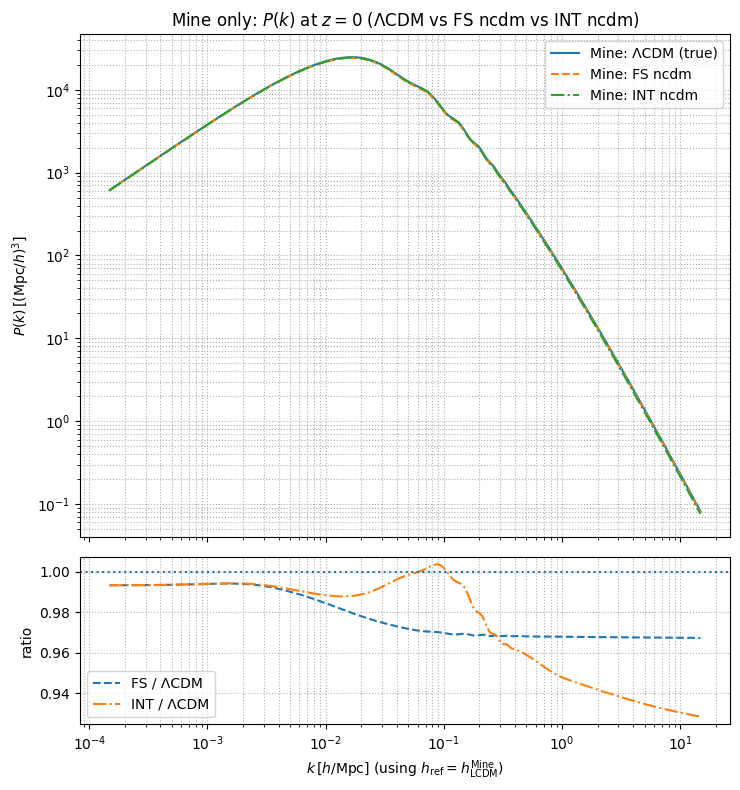

h_ref (Mine ΛCDM true) = 0.673200
max |FS/LCDM - 1|  = 0.0326715444816259
max |INT/LCDM - 1| = 0.07148510351780801

ALL DONE.


In [7]:
# =============================================================================
# Mine-only: overlay + ratios to true ΛCDM
# =============================================================================
print("\n==============================")
print("MINE ONLY: Overlay + Ratios")
print("==============================")

# Mine LCDM(true): again, NO ncdm count keys present
pM_lcdm2 = base_params(L_MAX)
pM_lcdm2.update({"N_ur": 3.046})
for key in [
    "N_ncdm", "N_ncdm_standard", "N_ncdm_interacting",
    "m_ncdm", "deg_ncdm", "T_ncdm",
    "m_ncdm_standard", "deg_ncdm_standard",
    "m_ncdm_interacting", "deg_ncdm_interacting",
    "G_eff_ncdm_interacting", "log10G_eff_ncdm_interacting",
    "G_eff_ncdm", "log10_G_eff_ncdm",
    "ncdm_fluid_approximation",
]:
    pM_lcdm2.pop(key, None)

# Mine FS
pM_fs2 = base_params(L_MAX)
pM_fs2.update({
    "N_ur"               : float(N_ur_run),
    "N_ncdm_standard"    : 1,
    "N_ncdm_interacting" : 0,
    "m_ncdm"             : float(M_NCDM_EV),
    "deg_ncdm"           : float(DEG_NCDM),
})
pM_fs2.pop("N_ncdm", None)

# Mine INT
pM_int2 = base_params(L_MAX)
pM_int2.update({
    "N_ur"                   : float(N_ur_run),
    "N_ncdm_standard"        : 0,
    "N_ncdm_interacting"     : 1,
    "m_ncdm"                 : float(M_NCDM_EV),
    "deg_ncdm"               : float(DEG_NCDM),
    "G_eff_ncdm_interacting" : float(G_EFF_NCDM_ON),
})
pM_int2.pop("N_ncdm", None)

cM_lcdm2 = run(ClassMine, pM_lcdm2, "Mine ΛCDM (true)")
cM_fs2   = run(ClassMine, pM_fs2,   "Mine FS ncdm")
cM_int2  = run(ClassMine, pM_int2,  "Mine INT ncdm")

h_ref_m  = float(cM_lcdm2.h())
k_hMpc_m = K_1MPC / h_ref_m

Pk_lcdm = pk_safe(cM_lcdm2, K_1MPC, Z_PK) * h_ref_m**3
Pk_fs   = pk_safe(cM_fs2,   K_1MPC, Z_PK) * h_ref_m**3
Pk_int  = pk_safe(cM_int2,  K_1MPC, Z_PK) * h_ref_m**3

r_fs  = Pk_fs / Pk_lcdm
r_int = Pk_int / Pk_lcdm

fig, (ax1, ax2) = plt.subplots(
    2, 1, figsize=(7.5, 8.0),
    sharex=True,
    gridspec_kw={"height_ratios": [3, 1]}
)

ax1.loglog(k_hMpc_m, Pk_lcdm, label="Mine: ΛCDM (true)")
ax1.loglog(k_hMpc_m, Pk_fs,   ls="--", label="Mine: FS ncdm")
ax1.loglog(k_hMpc_m, Pk_int,  ls="-.", label="Mine: INT ncdm")
ax1.set_ylabel(r"$P(k)\,[(\mathrm{Mpc}/h)^3]$")
ax1.set_title(r"Mine only: $P(k)$ at $z=0$ (ΛCDM vs FS ncdm vs INT ncdm)")
ax1.legend()
ax1.grid(True, which="both", ls=":")

ax2.semilogx(k_hMpc_m, r_fs,  ls="--", label="FS / ΛCDM")
ax2.semilogx(k_hMpc_m, r_int, ls="-.", label="INT / ΛCDM")
ax2.axhline(1.0, ls=":")
ax2.set_xlabel(r"$k\,[h/\mathrm{Mpc}]$ (using $h_\mathrm{ref} = h_\mathrm{LCDM}^{\rm Mine}$)")
ax2.set_ylabel("ratio")
ax2.grid(True, which="both", ls=":")
ax2.legend()

plt.tight_layout()
plt.show()

print(f"h_ref (Mine ΛCDM true) = {h_ref_m:.6f}")
print("max |FS/LCDM - 1|  =", np.max(np.abs(r_fs  - 1.0)))
print("max |INT/LCDM - 1| =", np.max(np.abs(r_int - 1.0)))

cleanup(cM_lcdm2, cM_fs2, cM_int2)
print("\nALL DONE.")


MINE ONLY: Per-species G_eff_ncdm_species test (with full-length T_ncdm)
[Mine MIX: per-species G_eff_ncdm_species] h=0.673200
DEBUG split(prepass): legacy_flag=0 legacy_N=0  flag_std=1 flag_int=1  Nstd_in=2 Nint_in=2  => Nstd=2 Nint=2 Ntot=4 (local N_ncdm=4)
DEBUG split(Geff_final): Nstd=2 Nint=2 Ntot=4  Geff_species=0.000e+00,0.000e+00[Mine MIX: broadcast G_eff_ncdm_interacting] h=0.673200
,1.000e-01,1.000e-04
DEBUG split(prepass): legacy_flag=0 legacy_N=0  flag_std=1 flag_int=1  Nstd_in=2 Nint_in=2  => Nstd=2 Nint=2 Ntot=4 (local N_ncdm=4)
DEBUG split(Geff_final): Nstd=2 Nint=2 Ntot=4  Geff_species=0.000e+00,0.000e+00,1.000e-01,1.000e-01


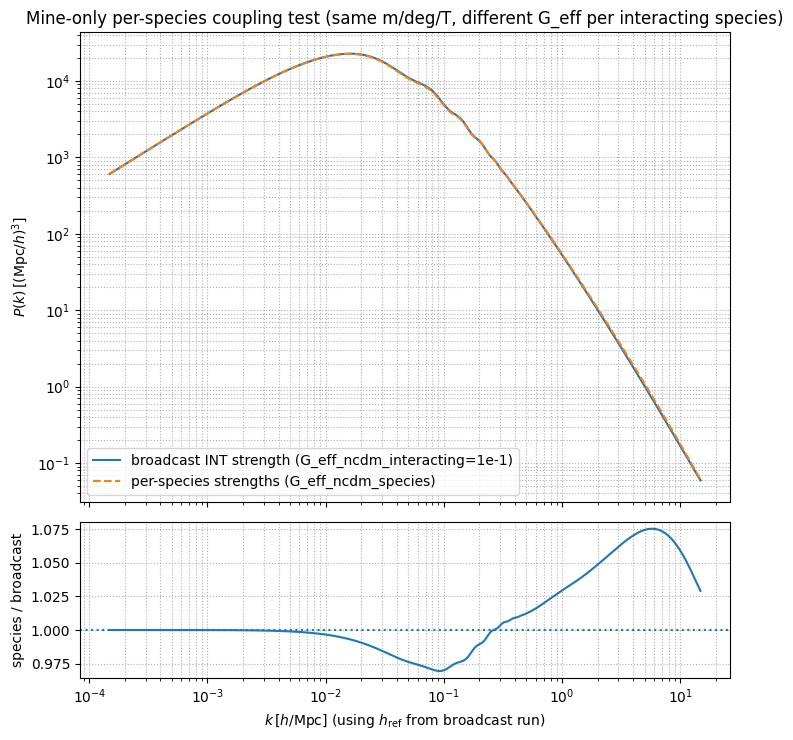

h_ref (broadcast run) = 0.673200
max |species/broadcast - 1| = 0.07547523049922633
DONE per-species test.


In [8]:
'''
This cell will compare two models with: 
    - Same cosmolgy
    - Same Nstd=2, Nint=2
    - same masses
    - same degeneracies

Difference:
    - Case A: all interacting species have Geff = 1e-1
    - Case B: interacting species have Geff^1 = 1e-1 and Geff^2 = 1e-4 
              Standard species remain Geff = 0
'''

# =============================================================================
# Per-species coupling test (Mine-only): FIXED for T_ncdm list-length
# =============================================================================

print("\n==============================")
print("MINE ONLY: Per-species G_eff_ncdm_species test (with full-length T_ncdm)")
print("==============================")

NSTD = 2
NINT = 2
NTOT = NSTD + NINT

m_list   = [0.00, 0.00, 0.06, 0.06]
deg_list = [1.00, 1.00, 1.00, 1.00]
T_list   = [T_ncdm_base] * NTOT   # <-- key fix: T_ncdm must have NTOT entries

G_list = [0.0, 0.0, 1e-1, 1e-4]   # standard slots are zero by construction

assert len(m_list) == NTOT and len(deg_list) == NTOT and len(T_list) == NTOT and len(G_list) == NTOT
assert all(G_list[i] == 0.0 for i in range(NSTD)), "Standard slots must be zero for free-streaming."

N_ur_mix = max(0.0, 3.046 - float(sum(deg_list)))

def as_list_str(x):
    return ",".join(f"{v:.8g}" for v in x)

# --- Per-species run (full override) ---
pM_species = base_params(L_MAX)
pM_species.update({
    "N_ur": float(N_ur_mix),
    "N_ncdm_standard": int(NSTD),
    "N_ncdm_interacting": int(NINT),

    #ensure N_ncdm_standard + N_ncdm_interacting = Ntot > 1 for all parameters below
    "m_ncdm":  as_list_str(m_list),
    "deg_ncdm": as_list_str(deg_list),
    "T_ncdm":  as_list_str(T_list),   

    "G_eff_ncdm_species": as_list_str(G_list),
})
pM_species.pop("N_ncdm", None)

# Remove competing coupling keys (keep only the full-length override)
for k in ["G_eff_ncdm_interacting", "log10G_eff_ncdm_interacting",
          "G_eff_ncdm_interacting_species", "log10_G_eff_ncdm_interacting_species",
          "log10_G_eff_ncdm_species"]:
    pM_species.pop(k, None)

# --- Broadcast run (for comparison) ---
pM_broadcast = base_params(L_MAX)
pM_broadcast.update({
    "N_ur": float(N_ur_mix),
    "N_ncdm_standard": int(NSTD),
    "N_ncdm_interacting": int(NINT),

    #ensure N_ncdm_standard + N_ncdm_interacting = Ntot > 1 for all parameters below
    "m_ncdm":  as_list_str(m_list),
    "deg_ncdm": as_list_str(deg_list),
    "T_ncdm":  as_list_str(T_list),   

    "G_eff_ncdm_interacting": 1e-1,
})
pM_broadcast.pop("N_ncdm", None)

# Ensure no full override is present in broadcast case
for k in ["G_eff_ncdm_species", "log10_G_eff_ncdm_species",
          "G_eff_ncdm_interacting_species", "log10_G_eff_ncdm_interacting_species",
          "log10G_eff_ncdm_interacting"]:
    pM_broadcast.pop(k, None)

# ---- Run ----
cM_species   = run(ClassMine, pM_species,   "Mine MIX: per-species G_eff_ncdm_species")
cM_broadcast = run(ClassMine, pM_broadcast, "Mine MIX: broadcast G_eff_ncdm_interacting")

# ---- P(k) + ratio ----
h_ref = float(cM_broadcast.h())
k_hMpc = K_1MPC / h_ref

Pk_species   = pk_safe(cM_species,   K_1MPC, Z_PK) * h_ref**3
Pk_broadcast = pk_safe(cM_broadcast, K_1MPC, Z_PK) * h_ref**3

ratio = Pk_species / Pk_broadcast

fig, (ax1, ax2) = plt.subplots(
    2, 1, figsize=(7.5, 7.5),
    sharex=True,
    gridspec_kw={"height_ratios": [3, 1]}
)

ax1.loglog(k_hMpc, Pk_broadcast, label="broadcast INT strength (G_eff_ncdm_interacting=1e-1)")
ax1.loglog(k_hMpc, Pk_species,   ls="--", label="per-species strengths (G_eff_ncdm_species)")
ax1.set_ylabel(r"$P(k)\,[(\mathrm{Mpc}/h)^3]$")
ax1.set_title("Mine-only per-species coupling test (same m/deg/T, different G_eff per interacting species)")
ax1.legend()
ax1.grid(True, which="both", ls=":")

ax2.semilogx(k_hMpc, ratio)
ax2.axhline(1.0, ls=":")
ax2.set_xlabel(r"$k\,[h/\mathrm{Mpc}]$ (using $h_\mathrm{ref}$ from broadcast run)")
ax2.set_ylabel("species / broadcast")
ax2.grid(True, which="both", ls=":")

plt.tight_layout()
plt.show()

print(f"h_ref (broadcast run) = {h_ref:.6f}")
print("max |species/broadcast - 1| =", float(np.max(np.abs(ratio - 1.0))))

cleanup(cM_species, cM_broadcast)
print("DONE per-species test.")


SANITY CHECK: per-species == broadcast when G are identical on interacting slots
DEBUG split(prepass): legacy_flag=0 legacy_N=0  flag_std=1 flag_int=1  Nstd_in=2 Nint_in=2  => Nstd=2 Nint=2 Ntot=4 (local N_ncdm=4)
DEBUG split(Geff_final): Nstd=2 Nint=2 Ntot=4  Geff_species=0.000e+00,0.000e+00,1.000e-01[Mine: per-species (equal on interacting slots)] h=0.673200
,1.000e-01
DEBUG split(prepass): legacy_flag=0 legacy_N=0  flag_std=1 flag_int=1  Nstd_in=2 Nint_in=2  => Nstd=2 Nint=2 Ntot=4 (local N_ncdm=4)
DEBUG split(Geff_final): Nstd=2 Nint=2 Ntot=4  Geff_species=0.000e+00,0.000e+00,1.000e-01,1.000e-01
[Mine: broadcast (reference)] h=0.673200


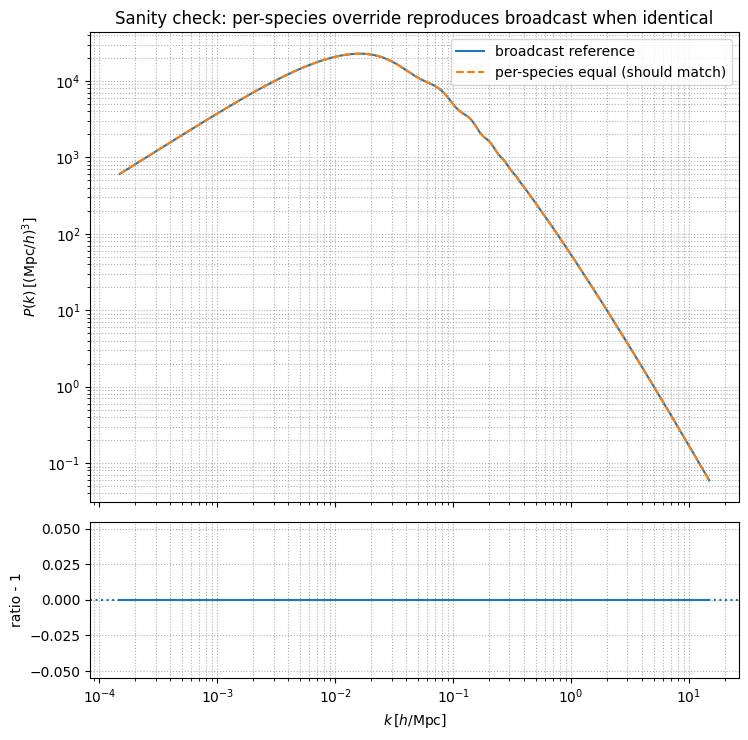

h_ref (broadcast ref) = 0.673200
max |ratio-1| = 0.0
median |ratio-1| = 0.0
DONE sanity check.


In [9]:
# =============================================================================
# Sanity check: per-species override == broadcast when all interacting G are equal
#   Expect: Pk_species_equal / Pk_broadcast  ~ 1 (numerical noise ~1e-6..1e-10)
# =============================================================================

print("\n==============================")
print("SANITY CHECK: per-species == broadcast when G are identical on interacting slots")
print("==============================")

# Reuse the same NSTD/NINT/NTOT, m_list, deg_list, T_list, N_ur_mix, and helper as_list_str
# from your previous per-species cell.
# If not in scope, redefine minimally here:
try:
    NSTD, NINT, NTOT
    m_list, deg_list, T_list
    N_ur_mix
    as_list_str
except NameError:
    raise RuntimeError("Run the previous per-species cell first so NSTD/NINT/... and lists are defined.")

G_BROADCAST = 1e-1

# Per-species list that matches broadcast on interacting indices
G_list_equal = [0.0]*NSTD + [G_BROADCAST]*NINT
assert len(G_list_equal) == NTOT

# --- Per-species (equal) ---
pM_species_equal = base_params(L_MAX)
pM_species_equal.update({
    "N_ur": float(N_ur_mix),
    "N_ncdm_standard": int(NSTD),
    "N_ncdm_interacting": int(NINT),

    "m_ncdm":  as_list_str(m_list),
    "deg_ncdm": as_list_str(deg_list),
    "T_ncdm":  as_list_str(T_list),

    "G_eff_ncdm_species": as_list_str(G_list_equal),
})
pM_species_equal.pop("N_ncdm", None)

# Remove any competing coupling keys
for k in ["G_eff_ncdm_interacting", "log10G_eff_ncdm_interacting",
          "G_eff_ncdm_interacting_species", "log10_G_eff_ncdm_interacting_species",
          "log10_G_eff_ncdm_species"]:
    pM_species_equal.pop(k, None)

# --- Broadcast (reference) ---
pM_broadcast_ref = base_params(L_MAX)
pM_broadcast_ref.update({
    "N_ur": float(N_ur_mix),
    "N_ncdm_standard": int(NSTD),
    "N_ncdm_interacting": int(NINT),

    "m_ncdm":  as_list_str(m_list),
    "deg_ncdm": as_list_str(deg_list),
    "T_ncdm":  as_list_str(T_list),

    "G_eff_ncdm_interacting": float(G_BROADCAST),
})
pM_broadcast_ref.pop("N_ncdm", None)

# Ensure no full override keys exist in broadcast run
for k in ["G_eff_ncdm_species", "log10_G_eff_ncdm_species",
          "G_eff_ncdm_interacting_species", "log10_G_eff_ncdm_interacting_species",
          "log10G_eff_ncdm_interacting"]:
    pM_broadcast_ref.pop(k, None)

# ---- Run ----
cM_species_equal = run(ClassMine, pM_species_equal, "Mine: per-species (equal on interacting slots)")
cM_broadcast_ref = run(ClassMine, pM_broadcast_ref, "Mine: broadcast (reference)")

# ---- Compare P(k) ----
h_ref = float(cM_broadcast_ref.h())
k_hMpc = K_1MPC / h_ref

Pk_species_equal = pk_safe(cM_species_equal, K_1MPC, Z_PK) * h_ref**3
Pk_broadcast_ref = pk_safe(cM_broadcast_ref, K_1MPC, Z_PK) * h_ref**3

ratio_eq = Pk_species_equal / Pk_broadcast_ref
dev_eq = ratio_eq - 1.0

# ---- Plot ----
fig, (ax1, ax2) = plt.subplots(
    2, 1, figsize=(7.5, 7.5),
    sharex=True,
    gridspec_kw={"height_ratios": [3, 1]}
)

ax1.loglog(k_hMpc, Pk_broadcast_ref, label="broadcast reference")
ax1.loglog(k_hMpc, Pk_species_equal, ls="--", label="per-species equal (should match)")
ax1.set_ylabel(r"$P(k)\,[(\mathrm{Mpc}/h)^3]$")
ax1.set_title("Sanity check: per-species override reproduces broadcast when identical")
ax1.legend()
ax1.grid(True, which="both", ls=":")

ax2.semilogx(k_hMpc, dev_eq)
ax2.axhline(0.0, ls=":")
ax2.set_xlabel(r"$k\,[h/\mathrm{Mpc}]$")
ax2.set_ylabel("ratio - 1")
ax2.grid(True, which="both", ls=":")

plt.tight_layout()
plt.show()

print(f"h_ref (broadcast ref) = {h_ref:.6f}")
print("max |ratio-1| =", float(np.max(np.abs(dev_eq))))
print("median |ratio-1| =", float(np.median(np.abs(dev_eq))))

cleanup(cM_species_equal, cM_broadcast_ref)
print("DONE sanity check.")